 Ejercicio 1


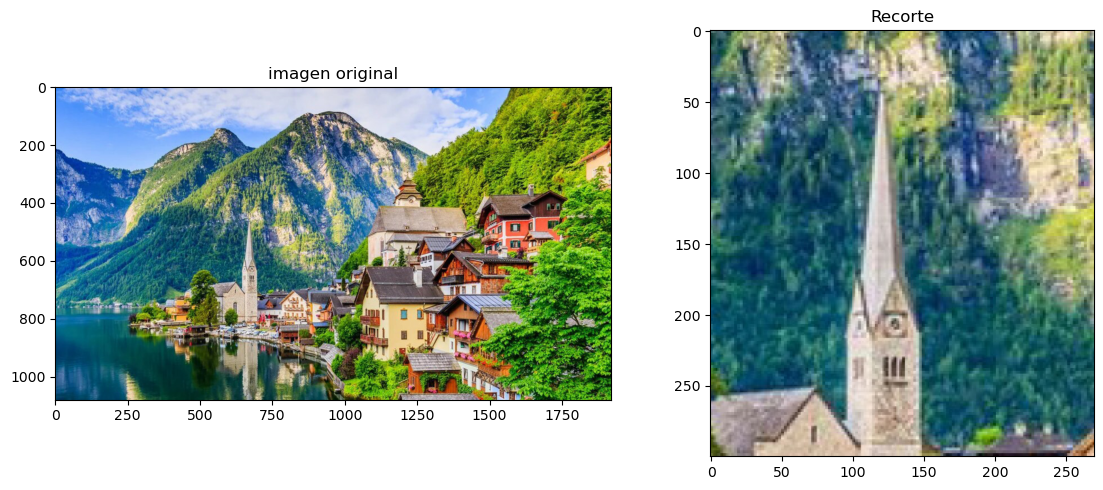

In [85]:
import cv2
import matplotlib.pyplot as plt
imagen_bgr = cv2.imread('imagenP.jpg.jpeg')
imagen_rgb = cv2.cvtColor(imagen_bgr,cv2.COLOR_BGR2RGB)

y1, y2 = 420, 720
x1, x2 = 550, 820
recorte_bgr = imagen_bgr[y1:y2, x1:x2]
recorte_rgb = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2RGB)

cv2.imwrite('recorte_ejercicio1.jpg', recorte_bgr)
plt.figure (figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagen_rgb)
plt.title('imagen original')
plt.axis('on')

plt.subplot(1, 2, 2)
plt.imshow(recorte_rgb)
plt.title('Recorte')
plt.axis('on')

plt.tight_layout()
plt.show()

ejer 2

Degradado lineal


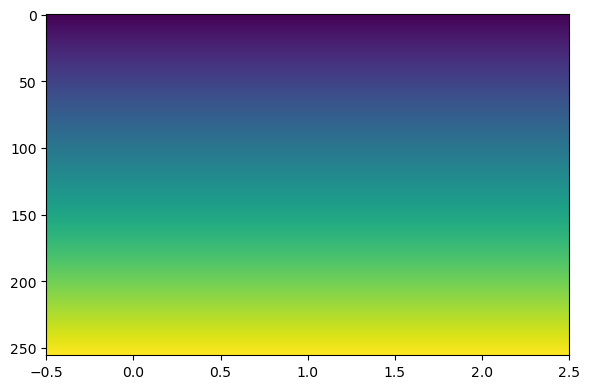

In [89]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

degradado = np.linspace(0, 1, 256).reshape(256, 1)
degradado = np.repeat(degradado, 256, axis=1)

plt.figure(figsize=(6, 4))
plt.imshow(degradado, aspect='auto', cmap='viridis', extent=(-0.5, 2.5, 255.5, -0.5))
plt.xticks(np.arange(-0.5, 2.6, 0.5))

plt.imsave('ejer2.png', degradado, cmap='viridis')
print('Degradado lineal')
plt.tight_layout()
plt.show()

ejer 3

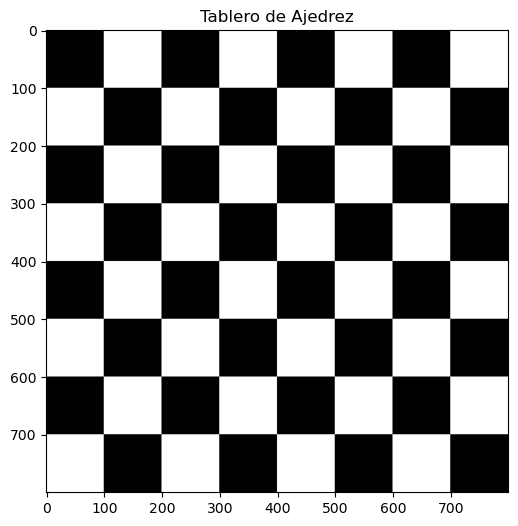

In [88]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

casilla = 100
n = 8

patron = (np.indices((n, n)).sum(axis=0) % 2) * 255
tablero = np.kron(patron, np.ones((casilla, casilla))).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(tablero, cmap='gray', vmin=0, vmax=255)
plt.title('Tablero de Ajedrez')
plt.xticks(np.arange(0, 800, 100))
plt.yticks(np.arange(0, 800, 100))
plt.show()

ejer 4

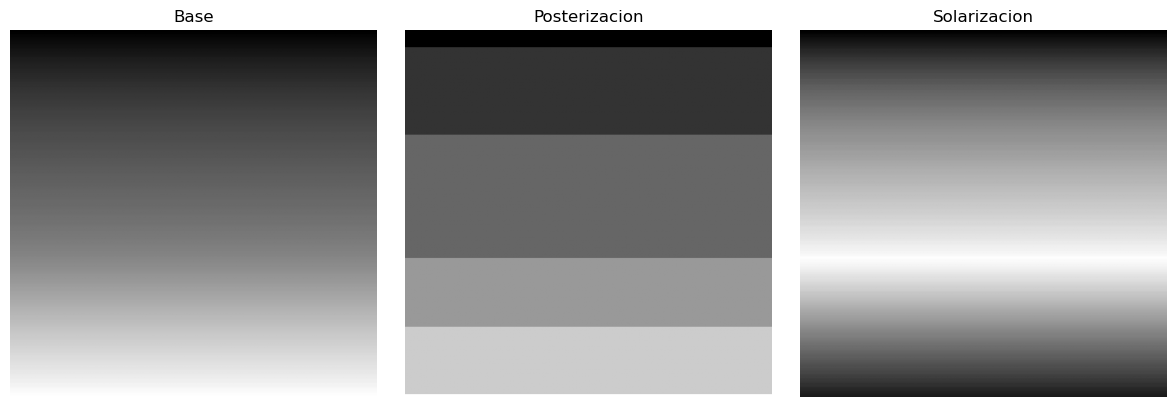

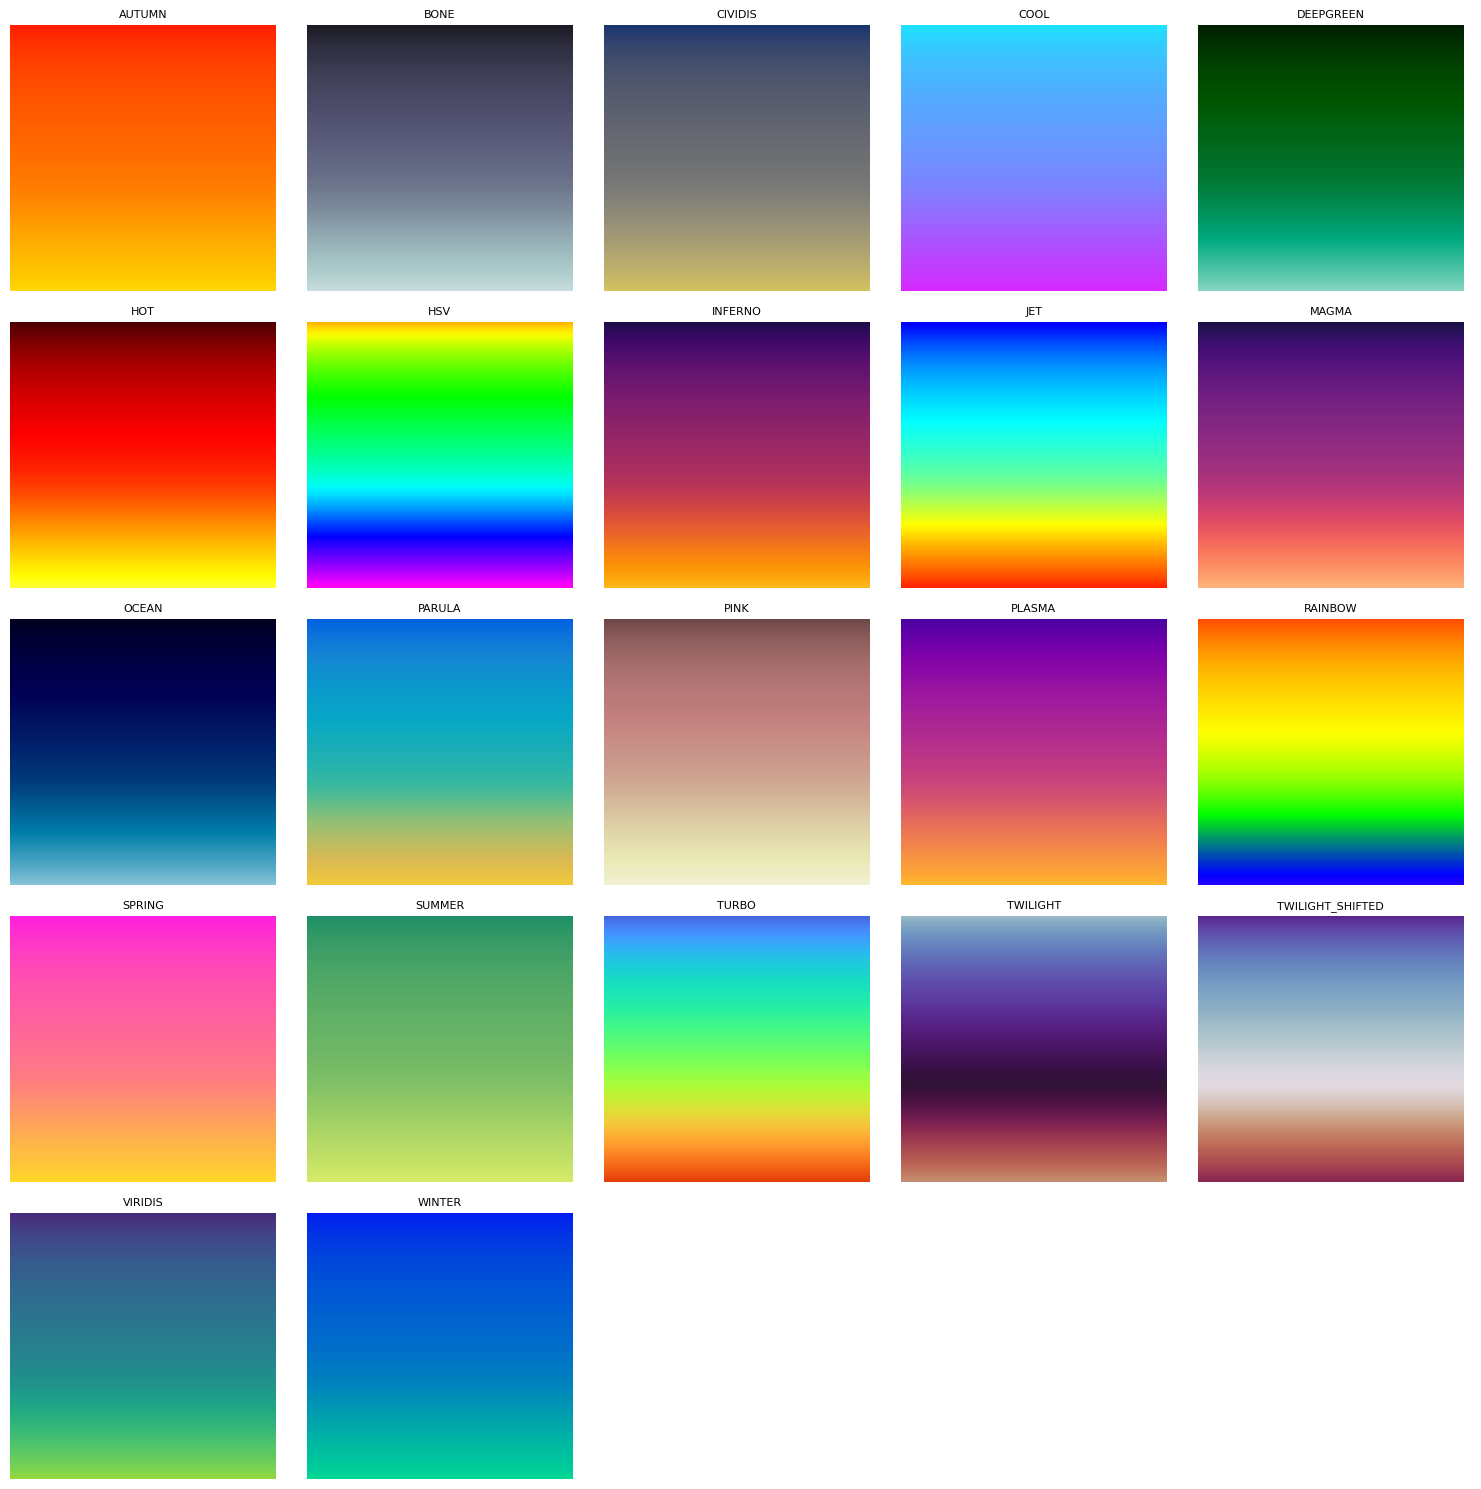

In [100]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_color = cv2.imread('ejer2.png')
gris = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

niveles = 6
gris_int = gris.astype(np.int32)
poster = ((gris_int * niveles) // 256) * (256 // niveles)
poster = poster.astype(np.uint8)

umbral = 127
solar = np.where(gris < umbral, gris, 255 - gris).astype(np.uint8)

cv2.imwrite('ejer4_base.png', gris)
cv2.imwrite('ejer4_poster.png', poster)
cv2.imwrite('ejer4_solar.png', solar)

paletas = [p for p in dir(cv2) if p.startswith('COLORMAP_')]
for p in paletas:
    color = cv2.applyColorMap(gris, getattr(cv2, p))
    cv2.imwrite(f'ejer4_{p}.png', color)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(gris, cmap='gray')
plt.title('Base')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(poster, cmap='gray')
plt.title('Posterizacion')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(solar, cmap='gray')
plt.title('Solarizacion')
plt.axis('off')

plt.tight_layout()
plt.show()

muestra = paletas[:25]
fig, axs = plt.subplots(5, 5, figsize=(15, 15))
axs = axs.ravel()

for i, p in enumerate(muestra):
    color = cv2.applyColorMap(gris, getattr(cv2, p))
    axs[i].imshow(cv2.cvtColor(color, cv2.COLOR_BGR2RGB))
    axs[i].set_title(p.replace('COLORMAP_', ''), fontsize=8)
    axs[i].axis('off')

for i in range(len(muestra), 25):
    axs[i].axis('off')

plt.tight_layout()
plt.show()

ejer 5

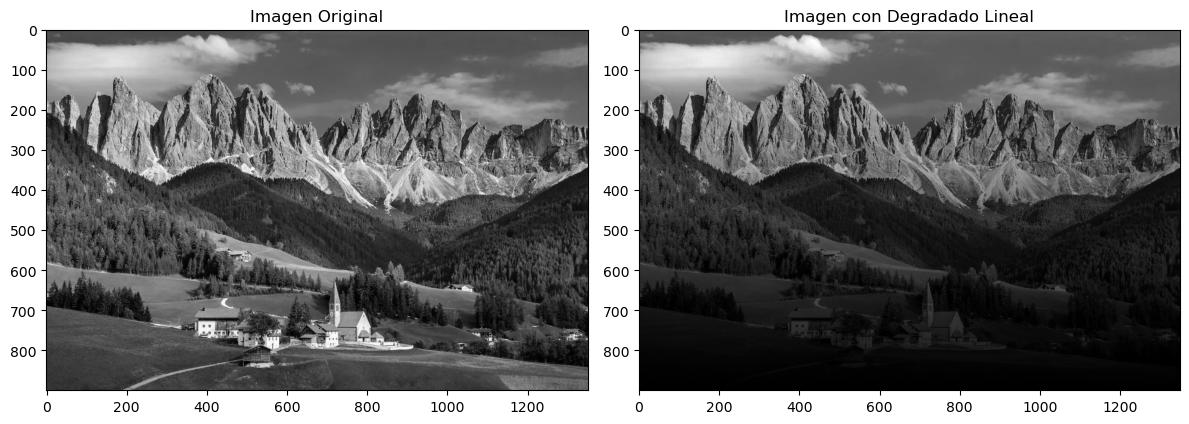

In [92]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen1.jpg.jpeg', cv2.IMREAD_GRAYSCALE)

h, w = img.shape
degradado = np.linspace(1.0, 0.0, h).reshape(h, 1)
img_degradada = (img * degradado).astype(np.uint8)

cv2.imwrite('ejer5.png', img_degradada)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('on')

plt.subplot(1, 2, 2)
plt.imshow(img_degradada, cmap='gray')
plt.title('Imagen con Degradado Lineal')
plt.axis('on')

plt.tight_layout()
plt.show()

ejer 6

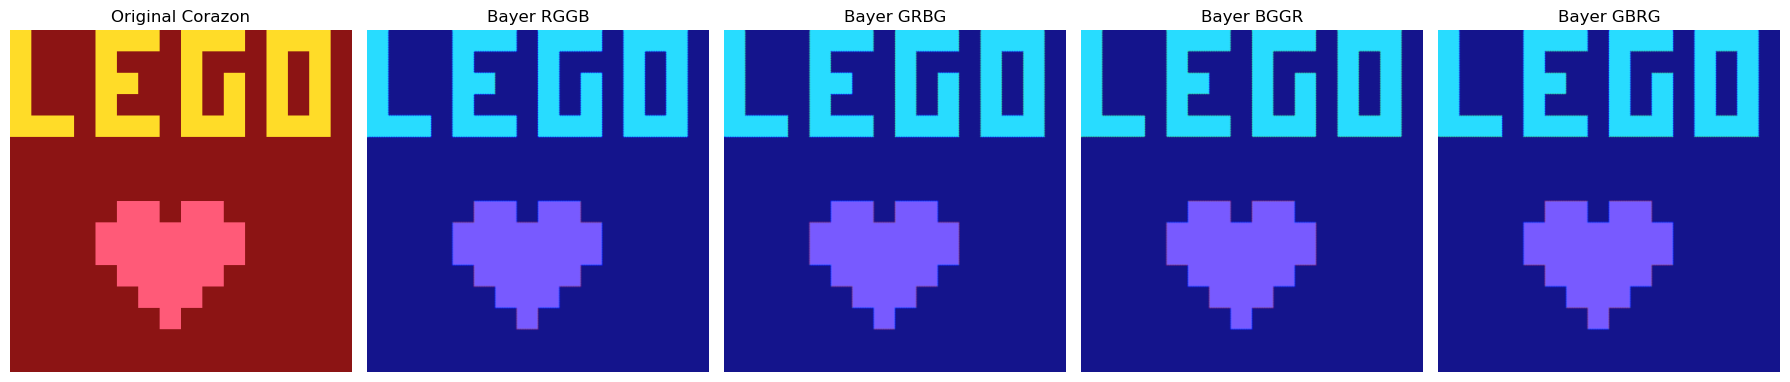

In [102]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

s = 25
grid = np.zeros((16, 16, 3), dtype=np.uint8)
grid[:] = (140, 20, 20)

def put(pattern, r0, c0, color):
    p = np.array(pattern, dtype=np.uint8)
    h, w = p.shape
    grid[r0:r0+h, c0:c0+w][p == 1] = color

L = [[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,1,1]]
E = [[1,1,1],[1,0,0],[1,1,0],[1,0,0],[1,1,1]]
G = [[1,1,1],[1,0,0],[1,0,1],[1,0,1],[1,1,1]]
O = [[1,1,1],[1,0,1],[1,0,1],[1,0,1],[1,1,1]]

for p, c in zip([L, E, G, O], [0, 4, 8, 12]):
    put(p, 0, c, (255, 220, 40))

corazon = [
    [0,1,1,0,1,1,0],
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1],
    [0,1,1,1,1,1,0],
    [0,0,1,1,1,0,0],
    [0,0,0,1,0,0,0]
]
put(corazon, 8, 4, (255, 90, 120))

img = np.kron(grid, np.ones((s, s, 1))).astype(np.uint8)
h, w = img.shape[:2]
r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]

patrones = {
    'RGGB': [(0, 0, r), (0, 1, g), (1, 0, g), (1, 1, b)],
    'GRBG': [(0, 0, g), (0, 1, r), (1, 0, b), (1, 1, g)],
    'BGGR': [(0, 0, b), (0, 1, g), (1, 0, g), (1, 1, r)],
    'GBRG': [(0, 0, g), (0, 1, b), (1, 0, r), (1, 1, g)]
}

codigos = {
    'RGGB': cv2.COLOR_BayerRG2BGR,
    'GRBG': cv2.COLOR_BayerGR2BGR,
    'BGGR': cv2.COLOR_BayerBG2BGR,
    'GBRG': cv2.COLOR_BayerGB2BGR
}

cv2.imwrite('ejer6_corazon_original.png', cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

resultados = {}
for nombre, reglas in patrones.items():
    raw = np.zeros((h, w), dtype=np.uint8)
    for i, j, ch in reglas:
        raw[i::2, j::2] = ch[i::2, j::2]
    bgr = cv2.cvtColor(raw, codigos[nombre])
    resultados[nombre] = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    cv2.imwrite(f'ejer6_corazon_{nombre}.png', bgr)

fig, axs = plt.subplots(1, 5, figsize=(18, 4))
axs[0].imshow(img)
axs[0].set_title('Original Corazon')
axs[0].axis('off')

for k, nombre in enumerate(['RGGB', 'GRBG', 'BGGR', 'GBRG'], 1):
    axs[k].imshow(resultados[nombre])
    axs[k].set_title(f'Bayer {nombre}')
    axs[k].axis('off')

plt.tight_layout()
plt.show()